# 模型选择，过拟合与欠拟合

过拟合：模型在训练数据上拟合的比潜在分布中更接近；用于对抗过拟合的技术称为正则化

## 训练误差与泛化误差

见书p140

过拟合：模型复杂度过高，对训练数据拟合过好，对新数据泛化能力差。


欠拟合：模型复杂度过低，对训练数据拟合过差，对新数据泛化能力好。（实则是训练数据和测试数据的表现都很差）

## 多项式回归

使用多项式回归的例子来验证这些概念

### 生成数据集

使用三阶多项式来生成训练和测试数据的标签：

$$
y = 5 + 1.2x -3.4 \frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + \epsilon, \epsilon \in N(0, 0.1^2)
$$

这里我们试图找到下面的d阶多项式来估计标签y
$$
\hat{y} = \sum_{i=0}^{d} w_i x^i
$$

模型的权重是$w_i$给出的，偏置是$w_0$给出的

np.power(base, exp)  三个用法
```
import numpy as np

np.power(2, 3)  # 2^3 = 8
np.power([2, 3], 2)  # [4, 9]
np.power([2, 3], [1, 2])  # [2^1, 3^2] = [2, 9]
```

如果传入的不是上面三种，base是(N, 1), exp是(N, 1),那么会自动触发广播机制，生成(N, N)的矩阵

In [ ]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))  # 特征为(n_train+n_test, 1)形的元组
np.random.shuffle(features)  # 随机打乱特征的顺序
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1)) # 
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)  # 注意，true_w的维度是(max_degree,)，poly_features的维度是(n_train+n_test, max_degree)，所以结果的维度是(n_train+n_test,)
labels += np.random.normal(scale=0.1, size=labels.shape)  # 为标签添加高斯噪声，scale表示集中在均值幅度内的范围

c:\Users\20249\.conda\envs\test1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


查看一下前面两个样本，第一个值是和偏置对应的常量特征

In [2]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 1.8330],
         [-1.3342]]),
 tensor([[ 1.0000e+00,  1.8330e+00,  1.6799e+00,  1.0264e+00,  4.7034e-01,
           1.7243e-01,  5.2675e-02,  1.3793e-02,  3.1603e-03,  6.4364e-04,
           1.1798e-04,  1.9659e-05,  3.0029e-06,  4.2340e-07,  5.5435e-08,
           6.7740e-09,  7.7604e-10,  8.3674e-11,  8.5207e-12,  8.2201e-13],
         [ 1.0000e+00, -1.3342e+00,  8.9001e-01, -3.9581e-01,  1.3202e-01,
          -3.5227e-02,  7.8332e-03, -1.4930e-03,  2.4899e-04, -3.6910e-05,
           4.9245e-06, -5.9728e-07,  6.6406e-08, -6.8152e-09,  6.4947e-10,
          -5.7767e-11,  4.8170e-12, -3.7804e-13,  2.8021e-14, -1.9676e-15]]),
 tensor([ 7.3473, -1.8004]))

## 对模型进行训练和测试

### 定义损失函数

In [3]:
import sys, os
sys.path.append(r"D:\Book\202603-202606\DeepLearning\code")
from utils.ch03 import Accumulator

def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]   # 返回的是损失函数的平均数值
    

### 定义训练函数

在这里损失函数选择平方损失

torch中关于loss的reduction可以设置三个变量：\
none：不聚合，保留每个样本的损失值\
mean：对每个样本的损失进行平均\
sum：对每个样本的损失进行求和


In [4]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')  # 
    input_shape = train_features.shape[-1]  # 获取train_features最后一个维度的大小，即特征维度（这里是深度学习的习惯，样本数一般是（样本数，特征维度））
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])  # 标签样本数
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)  # 这里面的reshape是把标签变成（样本数，1）的矩阵，因为损失函数需要标签是（样本数，1）的矩阵
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:  # 每20个epoch绘制一次动画
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

### 三阶多项式函数的拟合

首先使用三阶多项式函数，与数据生成函数的阶数相同

weight: [[ 5.0069447  1.2736871 -3.4107885  5.436784 ]]


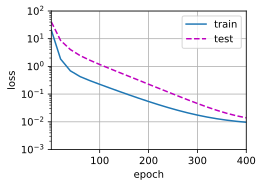

In [5]:
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

使用线性函数去拟合，即选择前两个维度(欠拟合)

weight: [[3.6004267 3.2228353]]


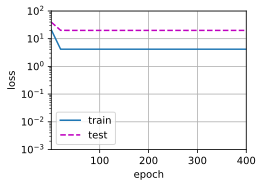

In [6]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

使用高阶函数去拟合（过拟合） 

weight: [[ 5.0019445   1.2398049  -3.3580215   5.292761   -0.23942213  1.4164412
  -0.16366787  0.26878846  0.03864519  0.20947737 -0.13667563  0.07921945
   0.21006855  0.02201052  0.03010066  0.07439014 -0.14639705 -0.10279297
   0.13486859  0.07589746]]


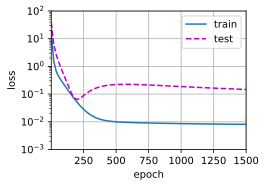

In [7]:
train(poly_features[:n_train], poly_features[n_train:], labels[:n_train], labels[n_train:], num_epochs=1500)


复杂数据对模型造成了过拟合